In [ ]:
# Extracción: Conexión a Drive y DuckDB.

from google.colab import drive

# Montar Drive
drive.mount('/content/drive')

base_path = '/content/drive/My Drive/Colab Notebooks/Predicción de crédito/'

application = base_path + 'application_train.csv'
bureau = base_path + 'bureau.csv'
payments = base_path + 'installments_payments.csv'
previous = base_path + 'previous_application.csv'

Mounted at /content/drive


In [ ]:
# Transformación (SQL): Limpieza y agregación de las 4 fuentes (Vistas).

import duckdb
import pandas as pd
import numpy as np

# Conexión en memoria
con = duckdb.connect(database=':memory:')

# 1. BUREAU: Historial en otras instituciones financieras
query_bureau = f"""
CREATE OR REPLACE VIEW bureau_agg AS
SELECT
    SK_ID_CURR,
    COUNT(*) AS n_creditos_buro,
    SUM(AMT_CREDIT_SUM_DEBT) AS deuda_externa_total,
    MAX(AMT_CREDIT_SUM_OVERDUE) AS mora_max_externa,
    SUM(CASE WHEN CREDIT_ACTIVE = 'Active' THEN 1 ELSE 0 END) AS creditos_activos_buro
FROM read_csv_auto('{bureau}')
GROUP BY SK_ID_CURR
"""

# 2. INSTALLMENTS: Comportamiento y Voluntad de Pago
query_install = f"""
CREATE OR REPLACE VIEW install_agg AS
SELECT
    SK_ID_CURR,
    -- ¿Paga lo que debe? (1.0 = pago exacto, <1.0 = pago incompleto)
    AVG(AMT_PAYMENT / NULLIF(AMT_INSTALMENT, 0)) AS ratio_cumplimiento_pago,

    -- ¿Paga a tiempo? (Valores positivos = días de atraso)
    AVG(DAYS_ENTRY_PAYMENT - DAYS_INSTALMENT) AS promedio_dias_atraso,

    -- Experiencia con nosotros
    COUNT(*) AS total_cuotas_pagadas
FROM read_csv_auto('{payments}')
GROUP BY SK_ID_CURR
"""

# 3. PREVIOUS APP: Memoria Interna (Historial de solicitudes en nuestra entidad)
query_prev = f"""
CREATE OR REPLACE VIEW prev_agg AS
SELECT
    SK_ID_CURR,
    -- Cantidad de veces que ha interactuado con nosotros
    COUNT(*) AS total_solicitudes_previas,

    -- El predictor "BRUTAL": ¿Qué tanto lo hemos rechazado?
    AVG(CASE WHEN NAME_CONTRACT_STATUS = 'Refused' THEN 1 ELSE 0 END) AS tasa_rechazo_interno,

    -- Carga financiera acumulada de contratos anteriores
    SUM(AMT_ANNUITY) AS monto_anualidad_previa
FROM read_csv_auto('{previous}')
GROUP BY SK_ID_CURR
"""


# 4. TABLA MAESTRA: Unión de las 4 fuentes (Consolidación Final)
query_master = f"""
SELECT
    app.SK_ID_CURR,
    app.TARGET,
    app.NAME_CONTRACT_TYPE AS tipo_contrato,
    app.AMT_INCOME_TOTAL AS ingreso_total,
    app.AMT_CREDIT AS monto_credito,
    app.AMT_ANNUITY AS monto_anualidad,
    app.DAYS_BIRTH / -365.0 AS edad_años,
    app.DAYS_EMPLOYED AS dias_empleado_raw,
    app.EXT_SOURCE_2 AS score_externo_2,
    app.EXT_SOURCE_3 AS score_externo_3,

    -- Bureau
    COALESCE(b.deuda_externa_total, 0) AS deuda_externa_total,
    COALESCE(b.mora_max_externa, 0) AS mora_max_externa,
    COALESCE(b.creditos_activos_buro, 0) AS creditos_activos_buro,

    -- Pagos
    COALESCE(i.ratio_cumplimiento_pago, 1.0) AS ratio_cumplimiento_pago,
    COALESCE(i.promedio_dias_atraso, 0) AS promedio_dias_atraso,

    -- Historial Interno
    COALESCE(p.tasa_rechazo_interno, 0) AS tasa_rechazo_interno,
    COALESCE(p.total_solicitudes_previas, 0) AS total_solicitudes_previas

FROM read_csv_auto('{application}') app
LEFT JOIN bureau_agg b ON app.SK_ID_CURR = b.SK_ID_CURR
LEFT JOIN install_agg i ON app.SK_ID_CURR = i.SK_ID_CURR
LEFT JOIN prev_agg p    ON app.SK_ID_CURR = p.SK_ID_CURR
"""

# --- AUDITORÍA (DQC) Y CALIDAD DE DATOS ---
def run_audit(con, tables):
    print(f"{' REPORTE DE AUDITORÍA DE DATOS ':=^40}")
    for table in tables:
        audit_query = f"""
        SELECT
            '{table}' as tabla,
            COUNT(*) as total_registros,
            SUM(CASE WHEN SK_ID_CURR IS NULL THEN 1 ELSE 0 END) as nulos_id,
            APPROX_COUNT_DISTINCT(SK_ID_CURR) as clientes_unicos
        FROM {table}
        """
        res = con.execute(audit_query).df()
        print(f"📊 Tabla: {res['tabla'][0].upper():<12} | Regs: {res['total_registros'][0]:>9} | Clientes: {res['clientes_unicos'][0]:>9}")
    print("="*40)

# Ejecutar el Pipeline de Vistas y Master
con.execute(query_bureau)
con.execute(query_install)
con.execute(query_prev)
df_master = con.execute(query_master).df()

# --- POST-PROCESAMIENTO ---
# Limpieza de error de sistema en antigüedad laboral
df_master['dias_empleado_raw'].replace(365243, np.nan, inplace=True)

# Creación de antigüedad en años (absoluto para consistencia)
df_master['años_empleado'] = df_master['dias_empleado_raw'].abs() / 365.0
df_master['años_empleado'].fillna(0, inplace=True)

# Correr auditoría para validar consistencia
run_audit(con, ['bureau_agg', 'install_agg', 'prev_agg'])
print(f"✅ Dataset consolidado: {df_master.shape[0]} filas y {df_master.shape[1]} columnas.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

/tmp/ipython-input-2189150298.py:115: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_master['dias_empleado_raw'].replace(365243, np.nan, inplace=True)
/tmp/ipython-input-2189150298.py:119: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

==== REPORTE DE AUDITORÍA DE DATOS =====


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

📊 Tabla: BUREAU_AGG   | Regs:    305811 | Clientes:    334106


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

📊 Tabla: INSTALL_AGG  | Regs:    339587 | Clientes:    400849


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

📊 Tabla: PREV_AGG     | Regs:    338857 | Clientes:    400849
✅ Dataset consolidado: 307511 filas y 18 columnas.


In [ ]:
# --- AUDITORÍA DE COMPLETITUD ---
def audit_nulls(df):
    null_report = df.isnull().sum().to_frame(name='nulos')
    null_report['porcentaje'] = (null_report['nulos'] / len(df)) * 100
    null_report = null_report.sort_values(by='porcentaje', ascending=False)

    print(f"{' REPORTE DE COMPLETITUD (NULOS) ':=^40}")
    print(null_report.head(5).round(2))
    print("="*40)

# Ejecutamos sobre la tabla maestra final
audit_nulls(df_master)

==== REPORTE DE COMPLETITUD (NULOS) ====
                   nulos  porcentaje
score_externo_3    60965       19.83
dias_empleado_raw  55374       18.01
score_externo_2      660        0.21
monto_anualidad       12        0.00
TARGET                 0        0.00


🏛️ 1. Bureau: El "Carácter" Externo

Es el historial de comportamiento en otras instituciones.

* deuda_externa_total: Mide el nivel de apalancamiento actual. Si ya debe mucho afuera, tiene menos "bolsillo" para pagarnos.

* mora_max_externa: Es una alerta roja. Si ha dejado de pagar a otros, es altamente probable que haga lo mismo con nosotros.

* creditos_activos_buro: Indica si el cliente es un usuario intensivo de crédito.

💳 2. Installments: La "Voluntad" de Pago

Aquí analizamos el hábito. No basta con pagar; hay que saber cómo paga.

* ratio_cumplimiento_pago: Detecta a los clientes que pagan "a cuentagotas" (menos del monto facturado). Un ratio < 1.0 es un síntoma temprano de estrés financiero.

* promedio_dias_atraso: El mejor predictor histórico. El cliente que se atrasa 3 días hoy, se atrasará 30 mañana.

🔄 3. Previous Application: La "Memoria" Interna

Esta es la información más valiosa porque es propia. Es lo que aprendimos del cliente en el pasado.

* tasa_rechazo_interno: Es un predictor "brutal". Si nuestros analistas (o modelos previos) rechazaron al cliente varias veces antes, suele ser porque detectaron riesgos que no siempre están en los números (documentación falsa, inconsistencias, etc.).

* total_solicitudes_previas: Mide la lealtad y recurrencia. Un cliente con muchas solicitudes aprobadas y pagadas es un "Cliente VIP".

🏠 4. Application: Es el formulario que el cliente llena hoy. Es la base sobre la cual construimos todo.

* EXT_SOURCE_2 y EXT_SOURCE_3: Son scores de burós externos (como Equifax o Experian) ya normalizados. Son tan potentes que no incluirlos sería desperdiciar el trabajo de otros modelos expertos.

* edad_años: La estabilidad financiera suele estar correlacionada con la madurez.

In [ ]:
# Ejecutamos en DuckDB
tabla_buró = con.execute('SELECT * FROM bureau_agg').fetchdf()
tabla_pagos = con.execute('SELECT * FROM install_agg').fetchdf()
tabla_previa = con.execute('SELECT * FROM prev_agg').fetchdf()
tabla_master = con.execute('SELECT * FROM df_master').fetchdf()

# Visualizamos el resultado
display(tabla_buró.head())
display(tabla_pagos.head())
display(tabla_previa.head())
display(tabla_master.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,SK_ID_CURR,n_creditos_buro,deuda_externa_total,mora_max_externa,creditos_activos_buro
0,435112,12,1042296.57,0.0,3.0
1,389599,8,1590718.50,0.0,3.0
2,242993,15,59809.50,0.0,2.0
3,303740,4,263056.50,0.0,1.0
4,311918,2,20835.00,0.0,1.0


,SK_ID_CURR,ratio_cumplimiento_pago,promedio_dias_atraso,total_cuotas_pagadas
0,179530,0.971429,-14.142857,35
1,176978,0.975000,-19.750000,40
2,123519,1.000000,-4.552846,123
3,152876,0.863636,-10.454545,22
4,151375,1.000000,-1.119048,42


,SK_ID_CURR,total_solicitudes_previas,tasa_rechazo_interno,monto_anualidad_previa
0,143068,8,0.000000,70731.765
1,300963,6,0.666667,44955.450
2,141539,13,0.384615,232291.575
3,360163,5,0.200000,36637.335
4,114302,5,0.200000,54740.745


,SK_ID_CURR,TARGET,tipo_contrato,ingreso_total,monto_credito,monto_anualidad,edad_años,dias_empleado_raw,score_externo_2,score_externo_3,deuda_externa_total,mora_max_externa,creditos_activos_buro,ratio_cumplimiento_pago,promedio_dias_atraso,tasa_rechazo_interno,total_solicitudes_previas,años_empleado
0,190814,0,Cash loans,144000.0,247500.0,10615.5,53.509589,-518.0,0.306729,NaN,0.000,0.0,0.0,0.906250,-5.687500,0.000000,3,1.419178
1,163478,0,Revolving loans,180000.0,270000.0,13500.0,34.589041,-3750.0,0.644282,NaN,0.000,0.0,0.0,0.888895,-3.655556,0.000000,5,10.273973
2,126302,0,Cash loans,180000.0,342000.0,18684.0,47.076712,-158.0,0.561713,0.258084,5917975.515,0.0,3.0,1.000000,-10.923077,0.000000,4,0.432877
3,146072,0,Cash loans,252000.0,1024290.0,36418.5,34.657534,-5457.0,0.524807,0.492060,5757585.795,0.0,2.0,0.991379,-7.258621,0.166667,12,14.950685
4,122442,0,Cash loans,90000.0,355320.0,34614.0,63.246575,NaN,0.393318,0.771362,579541.500,0.0,4.0,0.973856,-3.647059,0.000000,9,0.000000


In [ ]:
from scipy.stats import skew
from scipy.stats.mstats import winsorize
import numpy as np

# Creamos una copia de df_master antes de las transformaciones para comparación
df_antes = df_master.copy()

# 1. Tratamiento de Outliers (Winsorización)
# Mantenemos el techo en el percentil 99 para evitar distorsiones por valores extremos
cols_a_winsorizar = [
    'ingreso_total',
    'deuda_externa_total',
    'monto_credito',
    'monto_anualidad'
]

for col in cols_a_winsorizar:
    if col in df_master.columns:
        # Aplicamos el límite superior (0.01 = 1%) para "capar" la cola derecha
        df_master[col] = winsorize(df_master[col], limits=[0, 0.01])

# 2. Tratamiento de Asimetría (Logaritmo)
# En banca, variables como ingresos y deudas suelen estar muy sesgadas a la derecha
columnas_numericas = df_master.select_dtypes(include=[np.number]).columns
umbral_asimetria = 1.0

print(f"{' TRATAMIENTO DE ASIMETRÍA ':=^40}")
for col in columnas_numericas:
    # Ignoramos etiquetas y variables objetivo
    if col in ['TARGET', 'SK_ID_CURR']: continue

    asimetria_actual = df_master[col].skew()

    if abs(asimetria_actual) > umbral_asimetria:
        # Usamos log1p (logaritmo de x+1) para manejar valores en 0 de forma segura
        if df_master[col].min() >= 0:
            print(f"🚀 Transformando {col:<25} | Skew: {asimetria_actual:>6.2f}")
            df_master[col] = np.log1p(df_master[col])
        else:
            print(f"⚠️ {col:<25} | Skew: {asimetria_actual:>6.2f} (Contiene negativos, sin cambio)")

print("="*40)
print("✅ Saneamiento estadístico completado.")

======= TRATAMIENTO DE ASIMETRÍA =======
🚀 Transformando ingreso_total             | Skew:   1.35
🚀 Transformando monto_credito             | Skew:   1.02
⚠️ dias_empleado_raw         | Skew:  -1.97 (Contiene negativos, sin cambio)
⚠️ deuda_externa_total       | Skew:   3.61 (Contiene negativos, sin cambio)
🚀 Transformando mora_max_externa          | Skew: 192.75
🚀 Transformando creditos_activos_buro     | Skew:   1.45
🚀 Transformando ratio_cumplimiento_pago   | Skew: 164.20
⚠️ promedio_dias_atraso      | Skew:  25.06 (Contiene negativos, sin cambio)
🚀 Transformando tasa_rechazo_interno      | Skew:   1.81
🚀 Transformando total_solicitudes_previas | Skew:   2.24
🚀 Transformando años_empleado             | Skew:   2.05
✅ Saneamiento estadístico completado.


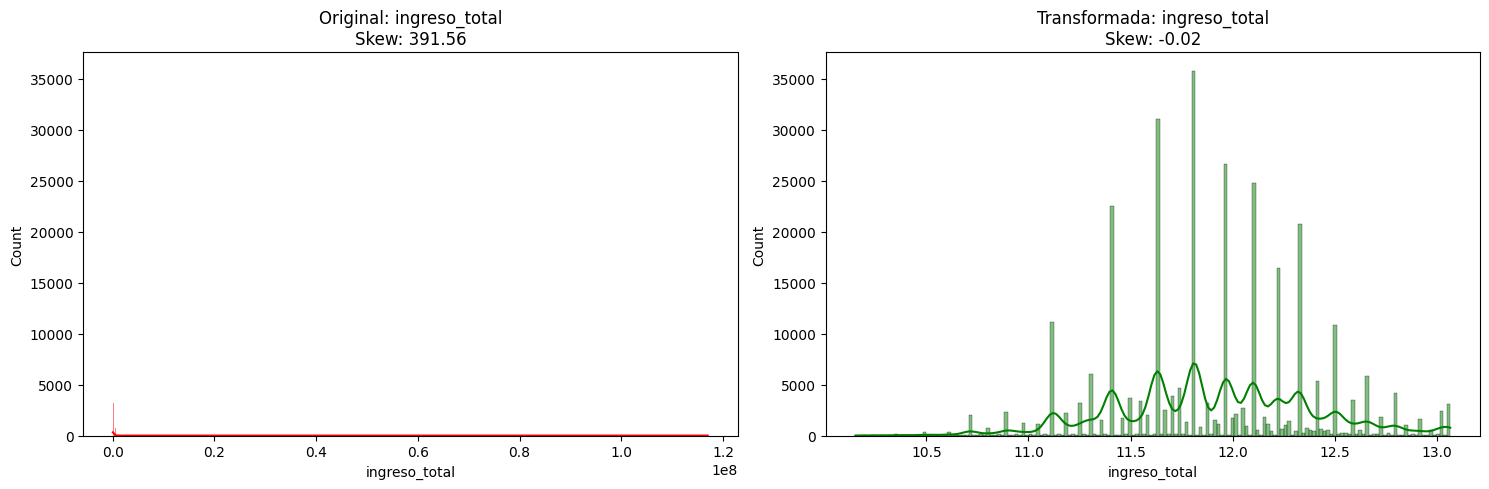

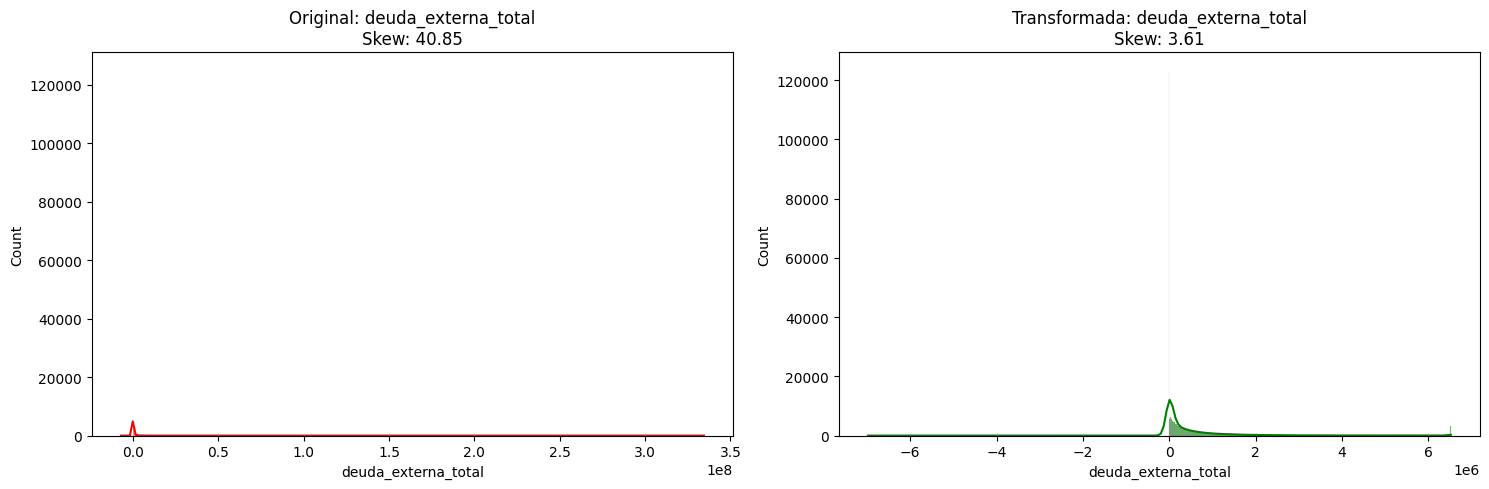

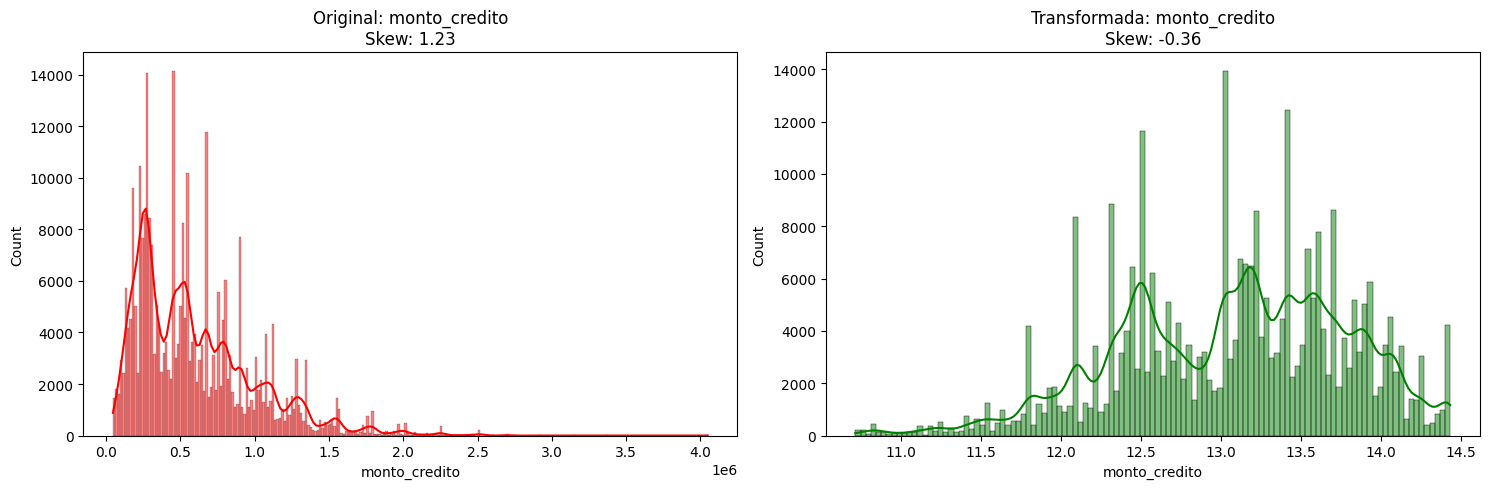

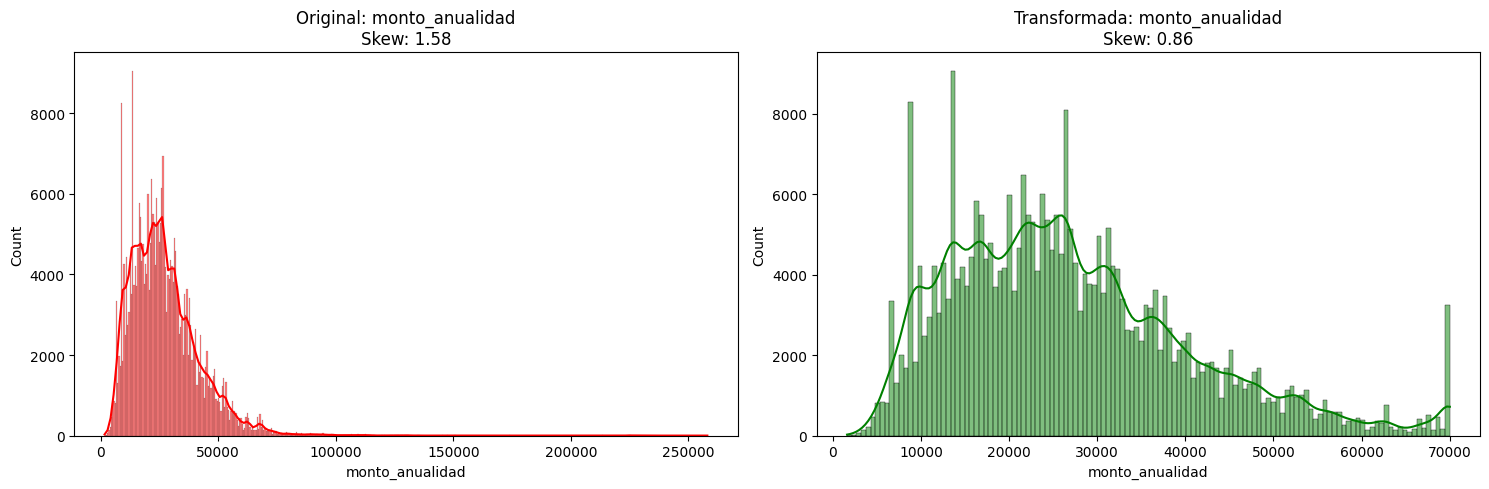

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_transformation_impact(df_original, df_transformed, column):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Antes del tratamiento
    sns.histplot(df_original[column], kde=True, ax=axes[0], color='red')
    axes[0].set_title(f'Original: {column}\nSkew: {df_original[column].skew():.2f}')

    # Después del tratamiento (Winsor + Log)
    sns.histplot(df_transformed[column], kde=True, ax=axes[1], color='green')
    axes[1].set_title(f'Transformada: {column}\nSkew: {df_transformed[column].skew():.2f}')

    plt.tight_layout()
    plt.show()


plot_transformation_impact(df_antes, df_master, 'ingreso_total')
plot_transformation_impact(df_antes, df_master, 'deuda_externa_total')
plot_transformation_impact(df_antes, df_master, 'monto_credito')
plot_transformation_impact(df_antes, df_master, 'monto_anualidad')

In [ ]:
# --- ENRIQUECIMIENTO: Inyección de Ratios de Negocio ---

# 1. Apalancamiento Global (Ratio de Endeudamiento Total)
# Mide cuánto debe el cliente (interno + externo) relativo a sus ingresos
df_master['RATIO_APALANCAMIENTO_GLOBAL'] = (df_master['deuda_externa_total'] + df_master['monto_credito']) / (df_master['ingreso_total'] + 1)

# 2. Fricción de Pago (Ponderación de mora interna y externa)
# Penalizamos fuertemente (100 puntos) si ya tiene mora reportada en el buró
df_master['SCORE_FRICCION_PAGO'] = df_master['promedio_dias_atraso'] + (np.where(df_master['mora_max_externa'] > 0, 100, 0))

# 3. Carga de la Cuota (Annuity Burden)
# Qué porcentaje de su ingreso mensual se va en pagar este crédito
df_master['RATIO_CARGA_CUOTA'] = df_master['monto_anualidad'] / (df_master['ingreso_total'] / 12 + 1)

# --- LIMPIEZA DE SEGURIDAD PARA NUEVOS RATIOS ---
cols_ratios = ['RATIO_APALANCAMIENTO_GLOBAL', 'SCORE_FRICCION_PAGO', 'RATIO_CARGA_CUOTA']

for col in cols_ratios:
    # Manejo de divisiones por cero o valores extremos
    df_master[col].replace([np.inf, -np.inf], np.nan, inplace=True)
    # Llenamos con la mediana para no sesgar la distribución
    df_master[col].fillna(df_master[col].median(), inplace=True)

print(f"{' NUEVOS RATIOS GENERADOS ':=^40}")
for col in cols_ratios:
    print(f"✔️ {col:<30} | Media: {df_master[col].mean():.4f}")
print("="*40)
print("✅ Ratios de negocio integrados y saneados.")

======= NUEVOS RATIOS GENERADOS ========
✔️ RATIO_APALANCAMIENTO_GLOBAL    | Media: 38670.4051
✔️ SCORE_FRICCION_PAGO            | Media: -9.5392
✔️ RATIO_CARGA_CUOTA              | Media: 13459.2580
✅ Ratios de negocio integrados y saneados.


/tmp/ipython-input-1016951868.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_master[col].replace([np.inf, -np.inf], np.nan, inplace=True)
/tmp/ipython-input-1016951868.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpla

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split

# --- 1. SELECCIÓN DE FEATURES ESTRATÉGICAS ---
features = [
    'ingreso_total',
    'edad_años',
    'años_empleado',
    'score_externo_2',
    'score_externo_3',
    'deuda_externa_total',
    'ratio_cumplimiento_pago',
    'tasa_rechazo_interno',
    'RATIO_APALANCAMIENTO_GLOBAL',
    'SCORE_FRICCION_PAGO',
    'RATIO_CARGA_CUOTA'
]

X = df_master[features]
y = df_master['TARGET']

# --- 2. SPLIT DE DATOS (80/20 con Estratificación) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 3. CONFIGURACIÓN DE RESTRICCIONES ---
constraints = {
    'ingreso_total': -1,
    'edad_años': -1,
    'años_empleado': -1,
    'score_externo_2': -1,
    'score_externo_3': -1,
    'deuda_externa_total': 1,
    'ratio_cumplimiento_pago': -1,
    'tasa_rechazo_interno': 1,
    'RATIO_APALANCAMIENTO_GLOBAL': 1,
    'SCORE_FRICCION_PAGO': 1,
    'RATIO_CARGA_CUOTA': 1
}

# Generamos la tupla mapeada
constraint_tuple = tuple([constraints.get(col, 0) for col in X_train.columns])

# --- 4. ENTRENAMIENTO CON PARÁMETROS BANCARIOS ---
model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=11,          # Trata el desbalanceo
    monotone_constraints=constraint_tuple,
    n_jobs=-1,
    random_state=42,
    early_stopping_rounds=50      # Previene overfitting
)

eval_set = [(X_train, y_train), (X_test, y_test)]

model.fit(
    X_train, y_train,
    eval_set=eval_set,
    verbose=50
)

print("\n✅ Modelo entrenado con éxito.")
print(f"📊 Clientes en Entrenamiento: {X_train.shape[0]}")
print(f"📊 Clientes en Validación: {X_test.shape[0]}")

[0]	validation_0-logloss:0.67545	validation_1-logloss:0.67548
[50]	validation_0-logloss:0.60891	validation_1-logloss:0.60967
[100]	validation_0-logloss:0.59578	validation_1-logloss:0.59692
[150]	validation_0-logloss:0.59186	validation_1-logloss:0.59344
[200]	validation_0-logloss:0.58947	validation_1-logloss:0.59143
[250]	validation_0-logloss:0.58780	validation_1-logloss:0.59001
[300]	validation_0-logloss:0.58650	validation_1-logloss:0.58895
[350]	validation_0-logloss:0.58591	validation_1-logloss:0.58853
[394]	validation_0-logloss:0.58606	validation_1-logloss:0.58886

✅ Modelo entrenado con éxito.
📊 Clientes en Entrenamiento: 246008
📊 Clientes en Validación: 61503


/tmp/ipython-input-1838600181.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=importancia_df, palette='magma')


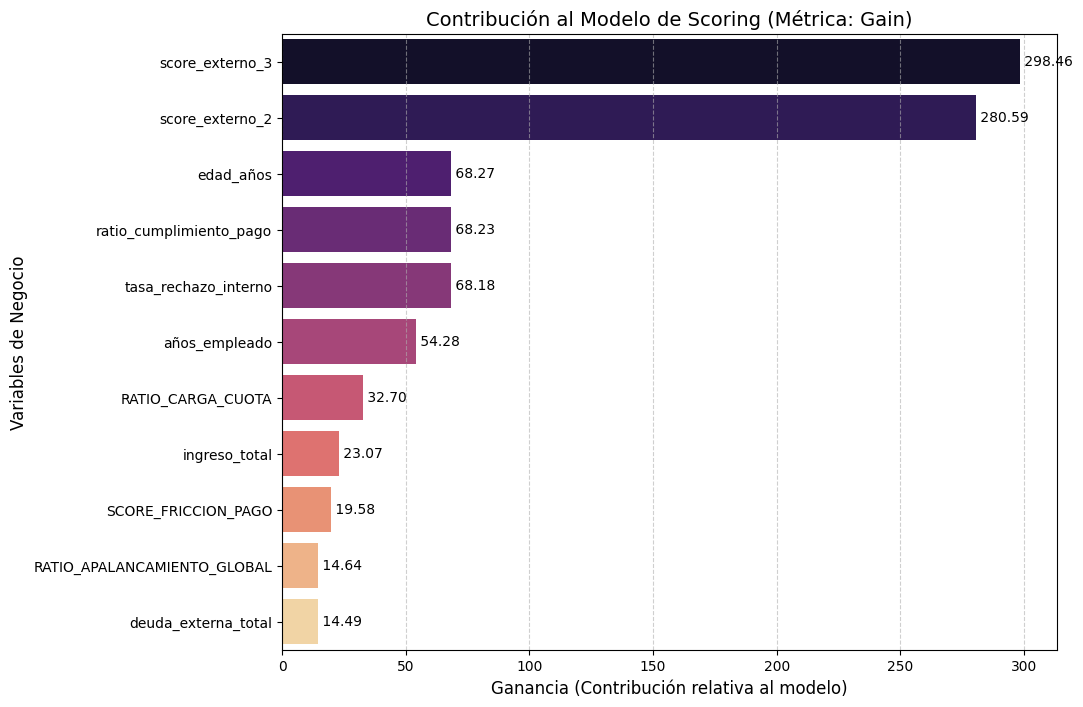


🏆 La variable con mayor poder predictivo es: score_externo_3


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extraer la importancia de las variables (usando 'gain' que es el más preciso para riesgos)
tipo_importancia = 'gain'
puntajes_importancia = model.get_booster().get_score(importance_type=tipo_importancia)

# 2. Convertir a DataFrame para graficar
importancia_df = pd.DataFrame({
    'Variable': list(puntajes_importancia.keys()),
    'Importancia': list(puntajes_importancia.values())
}).sort_values(by='Importancia', ascending=False)

# 3. Crear el gráfico visualmente atractivo
plt.figure(figsize=(10, 8))
sns.barplot(x='Importancia', y='Variable', data=importancia_df, palette='magma')

plt.title(f'Contribución al Modelo de Scoring (Métrica: {tipo_importancia.capitalize()})', fontsize=14)
plt.xlabel('Ganancia (Contribución relativa al modelo)', fontsize=12)
plt.ylabel('Variables de Negocio', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Añadir etiquetas de valor a las barras
for index, value in enumerate(importancia_df.Importancia):
    plt.text(value, index, f' {value:.2f}', va='center', fontsize=10)

plt.show()

# 4. Análisis de Resultados
variable_top = importancia_df.iloc[0]['Variable']
print(f"\n🏆 La variable con mayor poder predictivo es: {variable_top}")

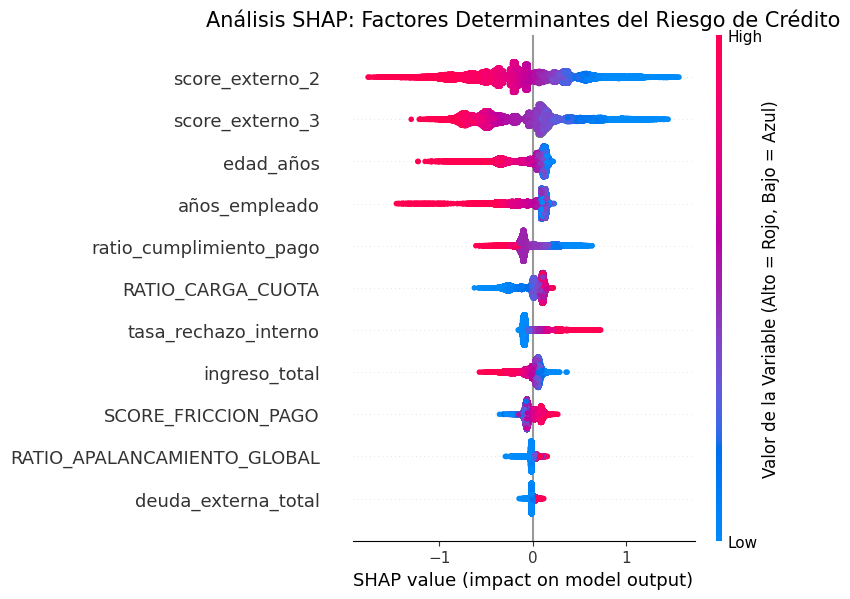

In [ ]:
import shap
import matplotlib.pyplot as plt

# 1. Crear el explicador (TreeExplainer es ideal para XGBoost)
# El modelo ya tiene las restricciones monotónicas y nombres en español
explainer = shap.TreeExplainer(model)

# 2. Calcular los valores SHAP para el conjunto de prueba
# Esto puede tardar unos segundos dependiendo del tamaño de X_test
shap_values = explainer.shap_values(X_test)

# 3. Visualización del Summary Plot
plt.figure(figsize=(12, 8))

# Personalizamos el gráfico para que se vea profesional
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="dot",
    show=False,
    color_bar_label="Valor de la Variable (Alto = Rojo, Bajo = Azul)"
)

plt.title("Análisis SHAP: Factores Determinantes del Riesgo de Crédito", fontsize=15)
plt.show()

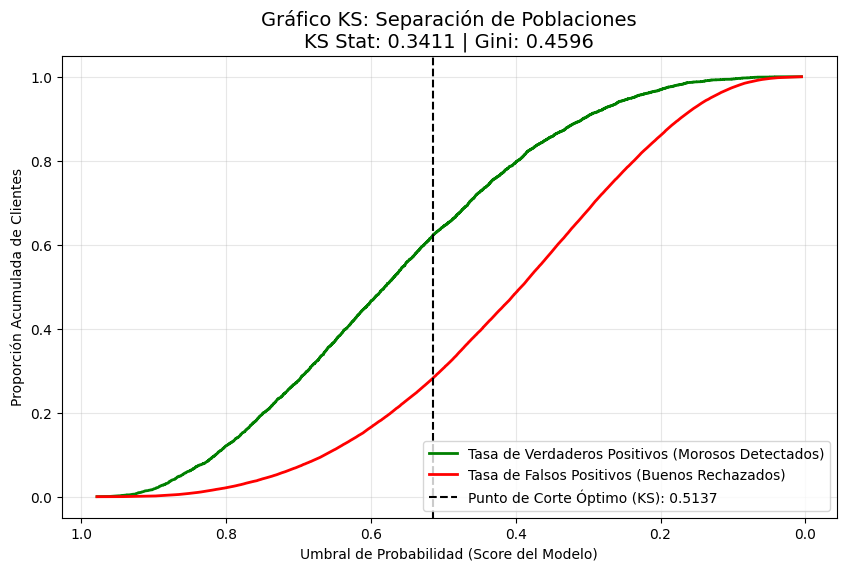

In [ ]:
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

# Re-split data to ensure consistency with the 'model' object trained in D1eB8pwbgiaz
X = df_master[features]
y = df_master['TARGET']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 1. Obtención de Probabilidades de Default
y_probs = model.predict_proba(X_test)[:, 1]

# 2. Métricas de Performance Core (Banca)
auc = roc_auc_score(y_test, y_probs)
gini = 2 * auc - 1  # Relación matemática Gini = 2*AUC - 1

# 3. Cálculo de Curva KS (Separación de poblaciones)
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
ks_values = tpr - fpr
max_ks_index = np.argmax(ks_values)
optimal_cutoff = thresholds[max_ks_index]
ks_stat = ks_values[max_ks_index]

# --- VISUALIZACIÓN: CURVA KS ---
plt.figure(figsize=(10, 6))
plt.plot(thresholds, tpr, label='Tasa de Verdaderos Positivos (Morosos Detectados)', color='green', lw=2)
plt.plot(thresholds, fpr, label='Tasa de Falsos Positivos (Buenos Rechazados)', color='red', lw=2)
plt.axvline(optimal_cutoff, color='black', linestyle='--', label=f'Punto de Corte Óptimo (KS): {optimal_cutoff:.4f}')

plt.title(f'Gráfico KS: Separación de Poblaciones\nKS Stat: {ks_stat:.4f} | Gini: {gini:.4f}', fontsize=14)
plt.xlabel('Umbral de Probabilidad (Score del Modelo)')
plt.ylabel('Proporción Acumulada de Clientes')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.gca().invert_xaxis() # El score se analiza de 1.0 (riesgo alto) a 0.0 (riesgo bajo)
plt.show()


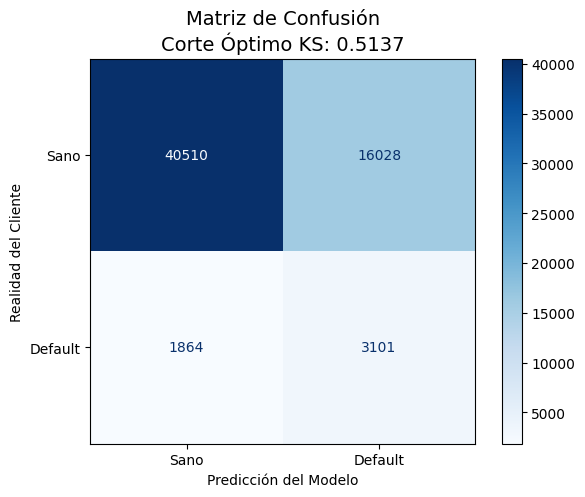


===== MÉTRICAS DE DESEMPEÑO FINAL ======
⭐ AUC Score:          0.7298
⭐ Coeficiente Gini:   0.4596
⭐ Estadístico KS:     0.3411
⭐ Umbral Seleccionado: 0.5137
🎯 Captura de Morosos: 62.46%
🚫 Falsa Alarma (FPR): 28.35%

==== REPORTE DE IMPACTO DE NEGOCIO =====
✅ Clientes Sanos Aprobados: 40510
🛡️ Default Prevenidos:      3101
⚠️ Costo Oportunidad (Buenos Rechazados): 16028
❌ Pérdida Directa (Morosos Filtrados):    1864


In [ ]:
# --- VISUALIZACIÓN 2: MATRIZ DE CONFUSIÓN ---
# Aplicamos el umbral donde la separación entre clases es máxima (KS)
y_pred_optimizado = (y_probs >= optimal_cutoff).astype(int)
cm = confusion_matrix(y_test, y_pred_optimizado)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sano', 'Default'])
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title(f'Matriz de Confusión\nCorte Óptimo KS: {optimal_cutoff:.4f}', fontsize=14)
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad del Cliente')
plt.show()

# --- REPORTE DE IMPACTO Y MÉTRICAS FINALES ---
tn, fp, fn, tp = cm.ravel()
tpr_final = tp / (tp + fn) # Recall
fpr_final = fp / (fp + tn) # Ratio de rechazo de buenos

print(f"\n{' MÉTRICAS DE DESEMPEÑO FINAL ':=^40}")
print(f"⭐ AUC Score:          {auc:.4f}")
print(f"⭐ Coeficiente Gini:   {gini:.4f}")
print(f"⭐ Estadístico KS:     {ks_stat:.4f}")
print(f"⭐ Umbral Seleccionado: {optimal_cutoff:.4f}")
print(f"🎯 Captura de Morosos: {tpr_final:.2%}")
print(f"🚫 Falsa Alarma (FPR): {fpr_final:.2%}")

print(f"\n{' REPORTE DE IMPACTO DE NEGOCIO ':=^40}")
print(f"✅ Clientes Sanos Aprobados: {tn}")
print(f"🛡️ Default Prevenidos:      {tp}")
print(f"⚠️ Costo Oportunidad (Buenos Rechazados): {fp}")
print(f"❌ Pérdida Directa (Morosos Filtrados):    {fn}")
print("="*40)

====== INICIANDO BENCHMARK DE SCORING =======
🚀 Entrenando Regresión Logística...
   >>> Gini: 0.4326
🚀 Entrenando Random Forest...
   >>> Gini: 0.4528
🚀 Entrenando XGBoost...
   >>> Gini: 0.4616


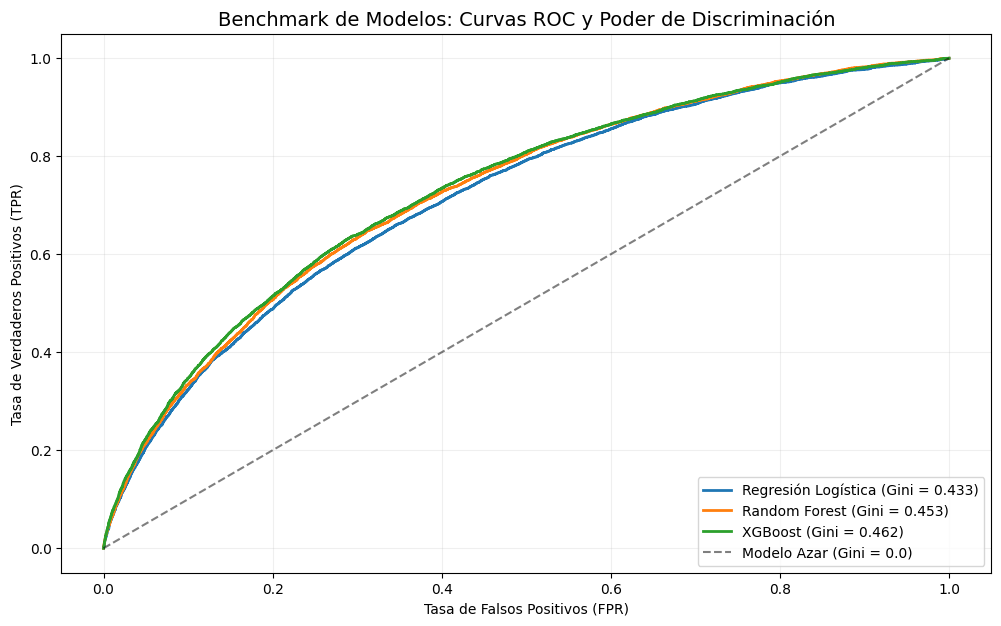


🏆 RANKING FINAL DE MODELOS:
                          auc      gini
XGBoost              0.730783  0.461567
Random Forest        0.726418  0.452836
Regresión Logística  0.716309  0.432617


In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- COMPARATIVA FINAL DE MODELOS (BENCHMARK) ---

# 1. Preparación con nombres en español
X = df_master[features]
y = df_master['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# --- DEFINICIÓN DE MODELOS ---

# A. Regresión Logística (Lógica Lineal - Baseline)
pipe_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', solver='liblinear', C=0.1))
])

# B. Random Forest (Ensamble de Árboles)
pipe_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', RandomForestClassifier(n_estimators=100, max_depth=8, class_weight='balanced', n_jobs=-1, random_state=42))
])

# C. XGBoost (Gradiente Descendente con Restricciones)
ratio_neg_pos = (y_train == 0).sum() / (y_train == 1).sum()
model_xgb = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=ratio_neg_pos,
    monotone_constraints=constraint_tuple, # Vital para cumplimiento regulatorio
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42
)

# --- COMPETENCIA DE MODELOS ---
resultados = {}

print(f"{' INICIANDO BENCHMARK DE SCORING ':=^45}")
for nombre, modelo in [('Regresión Logística', pipe_lr), ('Random Forest', pipe_rf), ('XGBoost', model_xgb)]:
    print(f"🚀 Entrenando {nombre}...")
    modelo.fit(X_train, y_train)

    preds = modelo.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, preds)
    gini = 2 * auc - 1
    resultados[nombre] = {'auc': auc, 'gini': gini, 'preds': preds}
    print(f"   >>> Gini: {gini:.4f}")

# --- VISUALIZACIÓN DE CURVAS ROC ---

plt.figure(figsize=(12, 7))
for nombre, res in resultados.items():
    fpr, tpr, _ = roc_curve(y_test, res['preds'])
    plt.plot(fpr, tpr, label=f"{nombre} (Gini = {res['gini']:.3f})", lw=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Modelo Azar (Gini = 0.0)')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Benchmark de Modelos: Curvas ROC y Poder de Discriminación', fontsize=14)
plt.legend(loc='lower right')
plt.grid(alpha=0.2)
plt.show()

# Ranking Final
resumen = pd.DataFrame(resultados).T[['auc', 'gini']].sort_values(by='gini', ascending=False)
print("\n🏆 RANKING FINAL DE MODELOS:")
print(resumen)